In [2]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 3.3 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 1.7 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.4 MB/s  0:00:01

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   ----

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

In [4]:
# Download once
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mak14\AppData\Roaming\nltk_data...


True

In [6]:
# Load dataset (local file from GitHub download)
df = pd.read_csv(r"C:\Users\mak14\Downloads\dataset\twitter_training.csv")

In [7]:
# Rename columns (based on dataset structure)
df.columns = ["id", "topic", "sentiment", "text"]

# Remove missing values
df.dropna(inplace=True)

# Initialize VADER
sia = SentimentIntensityAnalyzer()


In [8]:
# Function for sentiment classification
def analyze_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [9]:
# Apply sentiment analysis
df["Predicted_Sentiment"] = df["text"].apply(analyze_sentiment)


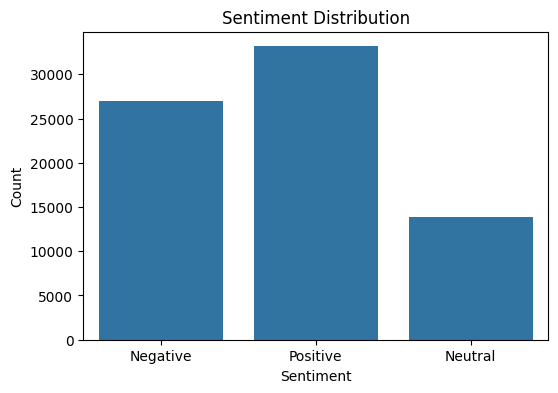

In [11]:
# 1. Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Predicted_Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


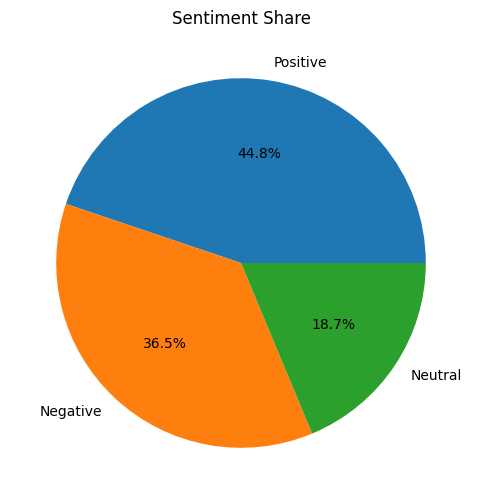

In [12]:
# 2. Pie Chart
sentiment_counts = df["Predicted_Sentiment"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Share")
plt.show()


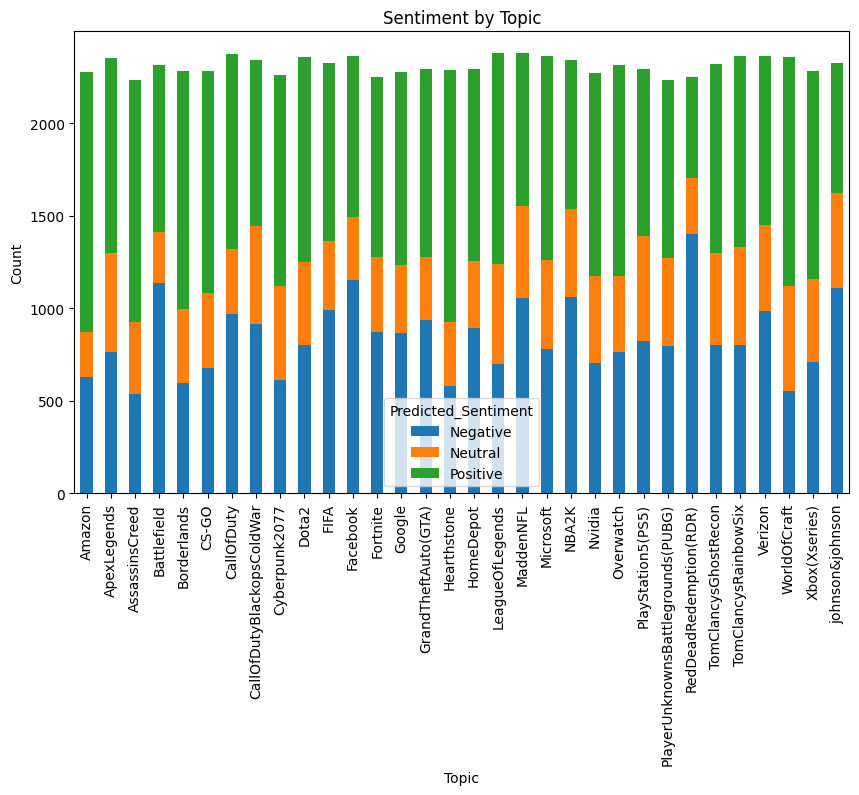

In [13]:
# 3. Sentiment by Topic
topic_sentiment = df.groupby(["topic", "Predicted_Sentiment"]).size().unstack()

topic_sentiment.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Sentiment by Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.show()